### Data Preparation

In [1]:
import gc
import os
import warnings
from copy import deepcopy

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import squidpy as sq
# import tiledb
# import tiledbsoma
from sklearn.preprocessing import LabelEncoder

/home/zhouwg/anaconda3/envs/nichecompass/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

In [3]:
# Define paths
st_data_folder_path = '/pri_exthome/zhouwg/project/spatial_data' # spatially resolved transcriptomics data
st_data_bronze_folder_path = f"{st_data_folder_path}/bronze"
st_data_silver_folder_path = f"{st_data_folder_path}/silver"
st_data_gold_folder_path = f"{st_data_folder_path}/gold"

# Create required directories
os.makedirs(st_data_bronze_folder_path, exist_ok=True)
os.makedirs(st_data_silver_folder_path, exist_ok=True)
os.makedirs(st_data_gold_folder_path, exist_ok=True)

## 2. Manuscript Data

This sections contains all datasets used for the manuscript.

### 2.1 seqFISH Mouse Organogenesis

- **Publication:** Lohoff, T. et al. Integration of spatial and single-cell transcriptomic data elucidates mouse organogenesis. Nat. Biotechnol. 40, 74–85 (2022): https://www.nature.com/articles/s41587-021-01006-2.
- **Data Access:** https://marionilab.cruk.cam.ac.uk/SpatialMouseAtlas/
- **Data Structure:**
    - ```
         ├── ../datasets/st_data/bronze/seqfish_mouse_organogenesis
         │  ├── metadata.Rds (metadata)
         │  ├── counts.Rds (raw counts)
         │  ├── exprs.Rds (log normalized counts)
         │  ├── imputed.h5 (imputed gene expression)
         │  ├── imputed_row_names.Rds (row names of imputed gene expression)
         │  ├── imputed_column_names.Rds (column names of imputed gene expression)
         ├── ../datasets/st_data/silver
         │  ├── seqfish_mouse_organogenesis.h5ad (preprocessed gene expression)
         │  ├── seqfish_mouse_organogenesis_imputed.h5ad (preprocessed imputed gene expression)
      ```
- **Summary:**
    - Sagittal tissue sections of three 8-12 somite stage mouse embryos
        - Two sections per embryo that can be combined horizontally to get three samples, one for each embryo
    - 19,451 observations (embryo 1), 14,891 observations (embryo 2) and 23,194 observations (embryo 3) on cell-level with cell-type annotations
    - 351 probed genes
    - Dataset is also available with imputed genes based on scRNA-seq

In [4]:
dataset = "seqfish_mouse_organogenesis"
cell_type_key = "celltype_mapped_refined"

#### 2.1.1 Load & Preprocess Raw Data

##### 2.1.1.1 Spatial Transcriptomics Data

Preprocessing is done with ```../scripts/data_preparation/seqfish_mouse_organogenesis_data_preparation.R``` and preprocessed version is stored under ```../datasets/st_data/silver/seqfish_mouse_organogenesis.h5ad```.

In [5]:
# Read preprocessed data
adata = sc.read_h5ad(f"{st_data_silver_folder_path}/{dataset}.h5ad")

# Filter low quality cells
adata = adata[adata.obs["celltype_mapped_refined"] != "Low quality"]

# Format adata
adata.obsm["spatial"] = np.column_stack((adata.obs.x, adata.obs.y))
adata.obs.drop(["x", "y"], axis=1, inplace=True)
adata.X = adata.X.astype(np.float32)
adata.layers["counts"] = adata.layers["counts"].astype(np.float32)

# Add sample & batch columns
adata.obs.loc[adata.obs.index.str.contains("embryo1"), "sample"] = "embryo1"
adata.obs.loc[adata.obs.index.str.contains("embryo2"), "sample"] = "embryo2"
adata.obs.loc[adata.obs.index.str.contains("embryo3"), "sample"] = "embryo3"

adata.obs.loc[adata.obs.index.str.startswith("embryo1") &
              adata.obs.index.str.endswith("z2"), "batch"] = "embryo1_z2"
adata.obs.loc[adata.obs.index.str.startswith("embryo1") &
              adata.obs.index.str.endswith("z5"), "batch"] = "embryo1_z5"
adata.obs.loc[adata.obs.index.str.startswith("embryo2") &
              adata.obs.index.str.endswith("z2"), "batch"] = "embryo2_z2"
adata.obs.loc[adata.obs.index.str.startswith("embryo2") &
              adata.obs.index.str.endswith("z5"), "batch"] = "embryo2_z5"
adata.obs.loc[adata.obs.index.str.startswith("embryo3") &
              adata.obs.index.str.endswith("z2"), "batch"] = "embryo3_z2"
adata.obs.loc[adata.obs.index.str.startswith("embryo3") &
              adata.obs.index.str.endswith("z5"), "batch"] = "embryo3_z5"
adata.write(f"{st_data_gold_folder_path}/{dataset}_final.h5ad")

# Write adata to disk separated by batches
batch_indeces = list(np.arange(6) + 1)
batches = ["embryo1_z2",
           "embryo1_z5",
           "embryo2_z2",
           "embryo2_z5",
           "embryo3_z2",
           "embryo3_z5"]

for batch_idx, batch in zip(batch_indeces, batches):
    adata_batch = adata[adata.obs["batch"] == batch]
    adata_batch.write(f"{st_data_gold_folder_path}/{dataset}_batch{batch_idx}.h5ad")

# Create adata for embryo 2 for single sample method benchmarking
# adata_embryo2 = adata[adata.obs["sample"] == "embryo2"]
# adata_embryo2.write(f"{st_data_gold_folder_path}/{dataset}_embryo2.h5ad")

### 2.2 Slide-seqV2 Mouse Hippocampus

- **Publication**: Stickels, R. R. et al. Highly sensitive spatial transcriptomics at near-cellular resolution with Slide-seqV2. Nat. Biotechnol. 39, 313–319 (2021). [doi:10.1038/s41587-020-0739-1](https://doi.org/10.1038/s41587-020-0739-1)
- **Data Access:** Preprocessed version from squidpy API (original source https://singlecell.broadinstitute.org/single_cell/study/SCP815/highly-sensitive-spatial-transcriptomics-at-near-cellular-resolution-with-slide-seqv2)
- **Summary:**
    - Mouse hippocampus puck
    - 41,786 observations on cell-level with cell-type annotations
    - 4,000 probed genes

In [6]:
dataset = "slideseqv2_mouse_hippocampus"
cell_type_key = "cell_type"

#### 2.2.1 Load & Preprocess Raw Data

##### 2.2.1.1 Spatial Transcriptomics Data

In [7]:
print(f"Loading and preprocessing dataset '{dataset}'.")

# Retrieve adata from squidpy
adata = sc.read_h5ad('/pri_exthome/zhouwg/project/spatial_data/slideseqv2/slideseqv2.h5ad') # sq.datasets.c()

# Create new adata to drop all unnecessary columns
adata_new = sc.AnnData(sp.csr_matrix(
    (adata.shape[0], adata.shape[1]),
    dtype=np.float32))
adata_new.X = adata.X
adata_new.var_names = adata.var_names
adata_new.obs_names = adata.obs_names
adata_new.obsm["spatial"] = adata.obsm["spatial"]
adata_new.obs["cell_type"] = adata.obs["cluster"].values

# Store raw counts in adata.layers
adata_new.layers["counts"] = sp.csr_matrix(np.round((np.exp(adata.X.toarray()) - 1)))

adata_new.obs["batch"] = "sample1"

# Store data to disk
adata_new.write(f"{st_data_gold_folder_path}/{dataset}_final.h5ad")

Loading and preprocessing dataset 'slideseqv2_mouse_hippocampus'.


### 2.4 nanoString CosMx SMI Human Non-Small-Cell Lung Cancer (NSCLC)

- **Publication:**
    - He, S. et al. High-plex imaging of RNA and proteins at subcellular resolution in fixed tissue by spatial molecular imaging. Nat. Biotechnol. 40, 1794–1806 (2022)
    - Tang, Z., Zhang, T., Yang, B., Su, J. & Song, Q. SiGra: Single-cell spatial elucidation through image-augmented graph transformer. bioRxiv (2022). [doi:10.1101/2022.08.18.504464v1](https://www.biorxiv.org/content/10.1101/2022.08.18.504464v1)
- **Data Access:**
    - https://nanostring.com/products/cosmx-spatial-molecular-imager/ffpe-dataset/
    - Preprocessed version available from SiGra: https://purdue0-my.sharepoint.com/:f:/g/personal/tang385_purdue_edu/EoJcJv8OZHRIhLyplj5r1PABW-UQfD1p1YU00gAdZNeK7A?e=K3Mmqg (lung 9 replicate 1 only; not used in the manuscript)
- **Data Structure**:
    - ```
         ├── ../datasets/st_data/bronze/nanostring_cosmx_human_nsclc
         │  └── raw
         │    └── Lung5_Rep1
         │      └── Lung5_Rep1-Flat_files_and_images (unannotated data)
         │    └── Lung5_Rep2
         │      └── Lung5_Rep2-Flat_files_and_images (unannotated data)
         │    └── Lung5_Rep3
         │      └── Lung5_Rep3-Flat_files_and_images (unannotated data)
         │    └── Lung6
         │      └── Lung6-Flat_files_and_images (unannotated data)
         │    └── Lung9_Rep1
         │      └── Lung9_Rep1-Flat_files_and_images (unannotated data)
         │    └── Lung9_Rep2
         │      └── Lung9_Rep2-Flat_files_and_images (unannotated data)
         │    └── Lung12
         │      └── Lung12-Flat_files_and_images (unannotated data)
         │    └── Lung13
         │      └── Lung13-Flat_files_and_images (unannotated data)
         │  └── metadata_giotto.csv
      ```
- **Summary:**
    - 8 tissue sections of non-small-cell lung cancer of human from 5 patients
        - 800,327 observations at cellular resolution without annotation
            - 93,206 observations lung5_rep1
            - 97,487 observations lung5_rep2
            - 91,691 observations lung5_rep3
            - 83,723 observations lung6
            - 77,391 observations lung9
            - 115,676 observations lung9_rep2
            - 66,489 observations lung12
            - 76,536 observations lung13
        - 83,621 observations at cellular resolution with annotations
    - 960 genes

In [8]:
dataset = "nanostring_cosmx_human_nsclc"
cell_type_key = "cell_type"

#### 2.4.1 Load & Preprocess Raw Data

##### 2.4.1.1 ST Data

In [9]:
batches = ["Lung5_Rep1",
           "Lung5_Rep2",
           "Lung5_Rep3",
           "Lung6",
           "Lung9_Rep1",
           "Lung9_Rep2",
           "Lung12",
           "Lung13"]

annotation_df = pd.read_csv(f"{st_data_bronze_folder_path}/{dataset}/metadata_giotto.csv", index_col=0)

for batch_idx, batch in enumerate(batches):
    gene_expr_df = pd.read_csv(f"{st_data_bronze_folder_path}/{dataset}/{batch}/{batch}-Flat_files_and_images/{batch}_exprMat_file.csv")
    metadata_df = pd.read_csv(f"{st_data_bronze_folder_path}/{dataset}/{batch}/{batch}-Flat_files_and_images/{batch}_metadata_file.csv")

    adata = ad.AnnData(gene_expr_df[gene_expr_df.columns.difference(["fov", "cell_ID"])].values,
                       obs=gene_expr_df[["fov", "cell_ID"]],
                       dtype="float32")
    adata.var_names = gene_expr_df.columns.difference(["fov", "cell_ID"])
    adata.obs["batch"] = batch.lower()

    # Add spatial coordinates from metadata
    adata.obs = pd.merge(adata.obs, metadata_df, on=["fov", "cell_ID"], how="left")
    adata.obsm["spatial"] = np.array(adata.obs[["CenterX_global_px", "CenterY_global_px"]])

    # Drop obs without metadata
    adata.obs.reset_index(drop=True, inplace=True)
    adata = adata[adata.obs.index.isin(adata.obs.dropna().index), :].copy()

    # Add cell type annotations, remove cells without annotations, and make fov unique across batches
    adata.obs["cell_ID"] = f"c_{batch_idx + 1}_" + adata.obs["fov"].astype("str") + "_" + adata.obs["cell_ID"].astype("str")
    adata.obs = pd.merge(adata.obs, annotation_df, on="cell_ID", how="left")
    adata.obs["fov"] = adata.obs["batch"] + "_" + adata.obs["fov_x"].astype(str)
    adata.obs = adata.obs[["cell_ID", "patient", "batch", "fov", "cell_type", "niche"]]
    adata.obs.index = adata.obs.index.astype(str)
    adata = adata[adata.obs.index.isin(adata.obs.dropna().index), :].copy()
    adata.obs.reset_index(drop=True, inplace=True)

    # Convert cell type annotations to coarser resolution
    adata.obs["cell_type_original"] = adata.obs["cell_type"].astype(str)
    adata.obs.loc[adata.obs["cell_type_original"].apply(
        lambda x: "T" in x),"cell_type"] = "NK/T cell"
    adata.obs.loc[adata.obs["cell_type_original"].apply(
        lambda x: "tumor" in x),"cell_type"] = "tumor"
    adata.obs.loc[adata.obs["cell_type_original"] == "NK","cell_type"] = "NK/T cell"
    adata.obs.loc[adata.obs["cell_type_original"].apply(
        lambda x: "DC" in x),"cell_type"] = "DC"
    adata.obs.loc[(adata.obs["cell_type_original"] == "monocyte") |
                  (adata.obs["cell_type_original"] == "macrophage") |
                  (adata.obs["cell_type"] == "DC"),"cell_type"] = "myeloid"

    # Remove negative probes
    adata.var.index = adata.var.index.map(str)
    adata = adata[:, ~adata.var_names.str.contains("NegPrb")].copy()

    # Remove low quality cells
    sc.pp.filter_cells(adata, min_counts=50)

    # Store gene expression in sparse format
    adata.X = sp.csr_matrix(np.array(adata.X))
    adata.layers["counts"] = adata.X.copy()

    # Log normalize counts
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    adata.write(f"{st_data_gold_folder_path}/{dataset}_batch{batch_idx + 1}.h5ad")

### 2.6 Xenium Human Breast Cancer

- **Publication:** Janesick, A. et al. High resolution mapping of the breast cancer tumor microenvironment using integrated single cell, spatial and in situ analysis of FFPE tissue. bioRxiv 2022.10.06.510405 (2022) doi:10.1101/2022.10.06.510405.
- **Data Access:**
    - https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast
    - Only sample 1 has been used but there is an additional sample
- **Data Structure:**
    - ```
         ├── ../datasets/st_data/bronze/xenium_human_breast_cancer
         │  ├── sample1/rep1
         │      ├── cell_feature_matrix.h5
         │      ├── cells.csv.gz
         │  ├── sample1/rep2
         │      ├── cell_feature_matrix.h5
         │      ├── cells.csv.gz
      ```
- **Summary:**
    - 2 FFPE tissue slice replicates of human breast cancer
    - 896,638 observations at cellular resolution without annotations
        - Sample 1, Replicate 1: 164,000 observations
        - Sample 1, Replicate 2: 118,363 observations
    - 313 probed genes

In [10]:
dataset = "xenium_human_breast_cancer"
cell_type_key = "cell_states"

#### 2.6.1 Load & Preprocess Raw Data

In [11]:
# Load and combine data
xenium_dir = f"{st_data_bronze_folder_path}/{dataset}/"
adata_rep1 = sc.read_10x_h5(filename=xenium_dir + "sample1/rep1/cell_feature_matrix.h5")
metadata_rep1 = pd.read_csv(xenium_dir + "sample1/rep1/cells.csv.gz")
adata_rep2 = sc.read_10x_h5(filename=xenium_dir + "sample1/rep2/cell_feature_matrix.h5")
metadata_rep2 = pd.read_csv(xenium_dir + "sample1/rep2/cells.csv.gz")

metadata_rep1.set_index(adata_rep1.obs_names, inplace=True)
adata_rep1.obs = metadata_rep1.copy()
adata_rep1.obsm["spatial"] = adata_rep1.obs[["x_centroid", "y_centroid"]].copy().to_numpy()
adata_rep1.obs.head()

metadata_rep2.set_index(adata_rep2.obs_names, inplace=True)
adata_rep2.obs = metadata_rep2.copy()
adata_rep2.obsm["spatial"] = adata_rep2.obs[["x_centroid", "y_centroid"]].copy().to_numpy()
adata_rep2.obs.head()

adata = adata_rep1.concatenate(adata_rep2, batch_key = 'replicates', batch_categories = ['Rep_1', 'Rep_2'], join = 'inner')
adata

AnnData object with n_obs × n_vars = 286532 × 313
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'replicates'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

In [12]:
metadata_rep2.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,cell_area,nucleus_area
1,1,479.934467,869.789633,207,0,0,207,166.310469,44.343438
2,2,481.256989,851.689365,147,0,0,147,218.420781,37.253906
3,3,490.647247,855.816202,165,0,0,165,110.723125,42.717813
4,4,491.177719,866.842908,186,0,0,186,181.482969,63.354219
5,5,492.839691,842.511191,82,0,0,82,152.989375,17.204531


In [13]:
## Perform basic QC analysis á la Squidpy
sc.pp.calculate_qc_metrics(adata, percent_top = (10, 20, 50, 150), inplace = True)

# Calculate percentage of control probes and control codewords
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.06707486296465286
Negative decoding count % : 0.006350175832931396


<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

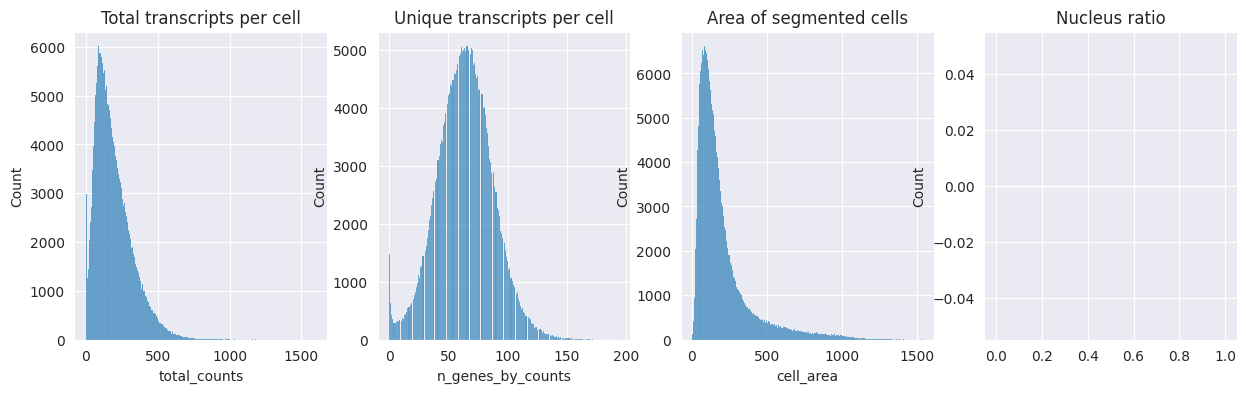

In [14]:
# Plot distribution of total transcripts per cell, unique transcripts per cell,
# area of segmented cells and the ratio of nuclei area to their cells
fig, axs = plt.subplots(1, 4, figsize = (15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata_rep1.obs["cell_area"],
    kde=False,
    ax=axs[3],
)

In [15]:
# Filter cells
sc.pp.filter_cells(adata, min_counts = 10)
sc.pp.filter_cells(adata, min_genes = 3)
sc.pp.filter_genes(adata, min_counts = 1)
sc.pp.filter_genes(adata, min_cells = 2)
adata

AnnData object with n_obs × n_vars = 282363 × 313
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'replicates', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    obsm: 'spatial'

In [16]:
# Normalize and transform data
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace = True)
sc.pp.log1p(adata)

In [17]:
# Visualize manifold
sc.pp.pca(adata, n_comps = 50, random_state = 1712)
sc.pp.neighbors(adata, n_neighbors = 50, random_state = 1769, method = 'umap')
sc.tl.leiden(adata, resolution = 2, random_state = 1786)
sc.tl.umap(adata, min_dist = 0.3, spread = 2, random_state = 1789)

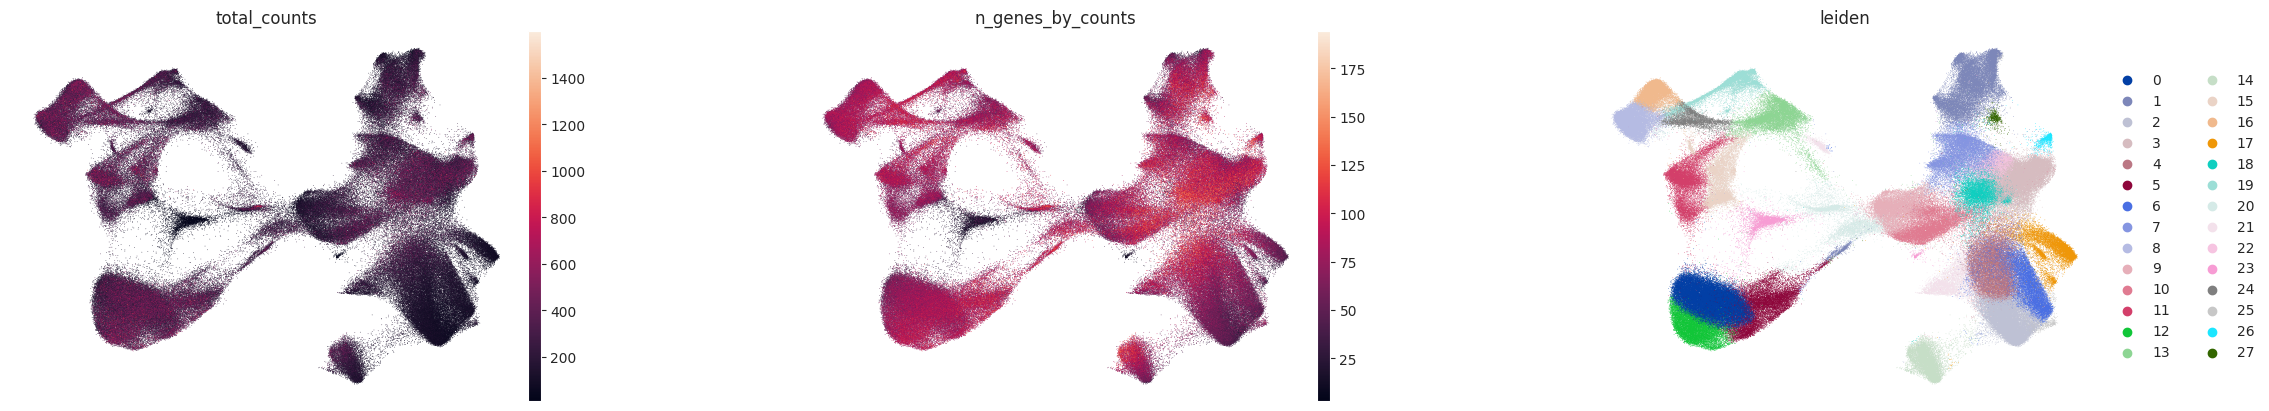

In [12]:
sc.pl.umap(
    adata,
    color = [
        "total_counts",
        "n_genes_by_counts",
        "leiden",
    ],
    wspace = 0.4,
    frameon = False,
    size = 1
)

In [13]:
# Characterize clusters
sc.tl.rank_genes_groups(adata, 'leiden', method = 'wilcoxon', n_genes = 100, use_raw = False)
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
markers_cells = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals_adj', 'logfoldchanges']})
markers_cells.head(5)

,0_n,0_p,0_l,1_n,1_p,1_l,2_n,2_p,2_l,3_n,3_p,3_l,4_n,4_p,4_l,5_n,5_p,5_l,6_n,6_p,6_l,7_n,7_p,7_l,8_n,8_p,8_l,9_n,9_p,9_l,10_n,10_p,10_l,11_n,11_p,11_l,12_n,12_p,12_l,13_n,13_p,13_l,14_n,14_p,14_l,15_n,15_p,15_l,16_n,16_p,16_l,17_n,17_p,17_l,18_n,18_p,18_l,19_n,19_p,19_l,20_n,20_p,20_l,21_n,21_p,21_l,22_n,22_p,22_l,23_n,23_p,23_l,24_n,24_p,24_l,25_n,25_p,25_l,26_n,26_p,26_l,27_n,27_p,27_l
0,FASN,0.0,2.824916,CAV1,0.0,4.011469,IL7R,0.0,4.584997,CXCL12,0.0,3.555815,TRAC,0.0,2.842274,FOXA1,0.0,2.141840,CD8A,0.0,5.469085,POSTN,0.0,3.442690,CEACAM6,0.0,3.555727,LYZ,0.0,4.251103,CD163,0.0,3.883889,SERPINA3,0.0,2.941998,TOP2A,0.0,3.774607,MYLK,0.0,4.502998,ITM2C,0.0,4.290562,CEACAM6,0.0,3.141754,SERPINA3,0.0,3.592595,CXCR4,0.0,2.819443,SFRP4,0.0,3.585549,KRT15,0.0,5.170247,CD68,0.0,3.553031,CD3E,0.0,2.553912,MMP2,0.0,3.666511,ERBB2,6.441639e-238,0.722854,CEACAM6,0.0,3.059731,IL7R,0.0,3.221339,ADH1B,0.0,6.803460,CAVIN2,6.128969e-293,5.450997
1,EPCAM,0.0,2.622061,CD93,0.0,4.446048,CD3E,0.0,4.054131,LUM,0.0,2.966939,IL7R,0.0,3.062276,EPCAM,0.0,2.079834,CCL5,0.0,4.621364,LUM,0.0,2.867433,TACSTD2,0.0,2.874452,FGL2,0.0,4.100877,MRC1,0.0,4.186090,AGR3,0.0,3.621527,EPCAM,0.0,2.515078,KRT14,0.0,5.362020,TENT5C,0.0,4.135370,TACSTD2,0.0,2.736083,CEACAM6,0.0,3.471104,MS4A1,0.0,6.841057,CCDC80,0.0,2.743978,SFRP1,0.0,4.067213,FCER1G,0.0,3.463657,CCL5,0.0,2.822001,POSTN,0.0,3.407339,KRT8,1.822387e-12,0.550655,KRT14,0.0,3.063371,VWF,0.0,3.781855,LPL,0.0,6.087562,PECAM1,6.137527e-270,2.977741
2,FOXA1,0.0,2.453065,PECAM1,0.0,3.909276,TRAC,0.0,3.859088,PDGFRA,0.0,3.396768,CD3E,0.0,2.736759,GATA3,0.0,1.832026,CD3E,0.0,3.405339,PDGFRB,0.0,3.131649,GATA3,0.0,2.526222,CD4,0.0,2.882410,CD14,0.0,3.878029,CCND1,0.0,1.684677,FOXA1,0.0,2.324107,DST,0.0,2.841058,SLAMF7,0.0,5.245634,KRT8,0.0,2.382975,GATA3,0.0,2.535549,BANK1,0.0,6.203150,LUM,0.0,2.426262,TACSTD2,0.0,2.965834,APOC1,0.0,4.396216,PTPRC,0.0,1.985625,CCDC80,0.0,3.182095,MMP12,1.188647e-05,2.908206,GATA3,0.0,2.129221,CD3E,0.0,2.784652,ADIPOQ,0.0,8.295361,MRC1,6.137527e-270,3.495839
3,KRT7,0.0,2.431644,AQP1,0.0,4.385550,PTPRC,0.0,3.332622,CCDC80,0.0,2.963218,PTPRC,0.0,2.173757,CCND1,0.0,1.475813,PTPRC,0.0,2.836525,RUNX1,0.0,1.969331,CD9,0.0,2.279954,AIF1,0.0,2.914320,PDK4,0.0,2.882024,SCD,0.0,2.228805,CENPF,0.0,3.893014,KRT5,0.0,5.308879,MZB1,0.0,4.968853,S100A14,0.0,2.576725,TACSTD2,0.0,2.348890,SELL,0.0,3.669673,FBLN1,0.0,2.728272,KRT23,0.0,5.947587,LYZ,0.0,2.597780,TRAC,0.0,2.065756,BASP1,0.0,2.682652,ELF5,3.921782e-03,2.484803,MYLK,0.0,2.409734,PECAM1,0.0,2.881784,PDK4,0.0,3.235337,KDR,1.316226e-223,3.875327
4,SCD,0.0,2.438918,VWF,0.0,4.836235,CXCR4,0.0,3.098699,FBLN1,0.0,3.288810,CXCR4,0.0,1.935829,KRT7,0.0,1.941680,TRAC,0.0,2.808926,ACTA2,0.0,2.145655,TPD52,0.0,1.782293,FCER1G,0.0,2.766862,FCER1G,0.0,2.939918,KRT8,0.0,2.049888,PCLAF,0.0,3.147062,ACTA2,0.0,2.418775,SEC11C,0.0,3.543067,KRT7,0.0,2.236634,MLPH,0.0,2.349161,PTPRC,0.0,2.283332,SFRP1,0.0,2.577723,KRT7,0.0,2.202408,HAVCR2,0.0,3.473607,CXCR4,0.0,1.737515,LUM,0.0,2.676283,CTSG,6.088270e-03,2.667402,TACSTD2,0.0,2.180381,PTPRC,0.0,2.242361,AKR1C1,0.0,4.642061,CAV1,2.610556e-211,2.830063


In [14]:
adata.obs['leiden'].cat.categories

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27'],
      dtype='object')

In [ ]:
adata.obs['cell_states'] = adata.obs['leiden'].copy() #
adata.obs['cell_states'] = adata.obs['cell_states'].cat.rename_categories(['Epi_ABCC11+', 'EC_CLEC14A+',  'tcm_CD4+T', 'Fib_CXCL12+', 'CD8+T', 'Epi_FOXA1+', 'eff_CD8+T','CD161+FOXP3+T',  'ADIPOQ+Mast',  'GJB2+iKC-FB', 'EMT-Epi1_CEACAM6+', 'DC1',
                                                                           'M2MØ', 'Epi_AGR3+', 'Epi_CENPF+', 'mgEpi_KRT14+', 'DERL3+B', 'EMT-Epi2_CEACAM6+', 'EMT-Epi_SERPINA3+', 'BANK1+B', 'EMT-Epi_KRT23+', 'MMP12+miMØ',
                                                                           'eff_CD8+T2', 'B', 'Epi_KRT14+', 'NK/T', 'EC_CAVIN2+'])
sc.pl.umap(adata, color = ['cell_states'], size = 0.8, legend_fontsize = 6, legend_loc = 'on data', frameon = False)

In [16]:
# Split replicates
adata_rep1 = adata[adata.obs['replicates'].isin(['Rep_1'])]
adata_rep2 = adata[adata.obs['replicates'].isin(['Rep_2'])]

In [17]:
adata_rep1.write(f"{st_data_gold_folder_path}/{dataset}_batch1.h5ad")
adata_rep2.write(f"{st_data_gold_folder_path}/{dataset}_batch2.h5ad")

In [27]:
adata_rep1.obs['leiden'].cat.categories

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27'],
      dtype='object')

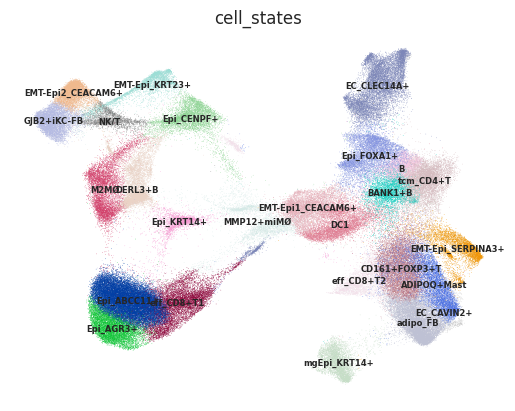

In [34]:
## 删除低质量的26, 群细胞
adata_rep1 = adata_rep1[~adata_rep1.obs['leiden'].isin(['26', '27'])]
adata_rep1.obs['cell_states'] = adata_rep1.obs['leiden'].copy()
adata_rep1.obs['cell_states'] = adata_rep1.obs['cell_states'].cat.rename_categories(['Epi_ABCC11+', 'EC_CLEC14A+', 'adipo_FB', 'tcm_CD4+T', 'CD161+FOXP3+T', 'eff_CD8+T1', 'ADIPOQ+Mast', 'Epi_FOXA1+', 'GJB2+iKC-FB', 'EMT-Epi1_CEACAM6+', 'DC1','M2MØ', 'Epi_AGR3+', 'Epi_CENPF+', 'mgEpi_KRT14+', 'DERL3+B', 'EMT-Epi2_CEACAM6+', 'EMT-Epi_SERPINA3+', 'BANK1+B', 'EMT-Epi_KRT23+', 'MMP12+miMØ',
                                                                           'eff_CD8+T2', 'B', 'Epi_KRT14+', 'NK/T', 'EC_CAVIN2+'])
sc.pl.umap(adata_rep1, color = ['cell_states'], size = 0.8, legend_fontsize = 6, legend_loc = 'on data', frameon = False)

In [20]:
adata_rep1 = sc.read_h5ad(f"{st_data_gold_folder_path}/{dataset}_batch1.h5ad")
adata_rep2 = sc.read_h5ad(f"{st_data_gold_folder_path}/{dataset}_batch2.h5ad")
adata_rep1

AnnData object with n_obs × n_vars = 164000 × 313
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'replicates', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [23]:
adata_rep2

AnnData object with n_obs × n_vars = 118363 × 313
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'replicates', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

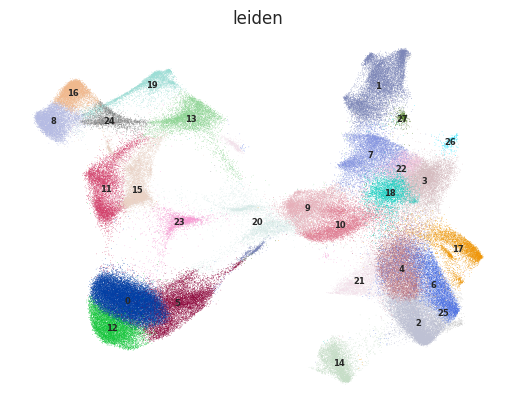

In [24]:
sc.pl.umap(adata_rep1, color = ['leiden'], size = 0.8, legend_fontsize = 6, legend_loc = 'on data', frameon = False)